# Advanced: Adjust simulation to ERA5 Atmospheric Profiles

Integration of ERA5 reanalysis data for realistic atmospheric profile input to radiative transfer simulations.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import gcsfs
import os

# we use the GCSFileSystem to access the ERA5 data stored in Google Cloud Storage
gcs = gcsfs.GCSFileSystem(token='anon')
path = 'gs://gcp-public-data-arco-era5/ar/1959-2022-6h-128x64_equiangular_with_poles_conservative.zarr/'
full_era5 = xr.open_zarr(gcs.get_mapper(path), chunks='auto')
#full_era5.to_netcdf('../data/era5_6h_128x64.nc', engine='h5netcdf')

/home/josh/micromamba/envs/mamba_josh/lib/python3.13/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [3]:
ds_arctic = full_era5.sel(time=slice('1980-01-01', '2020-01-02')).sel(latitude=slice(60, 90))

In [11]:
sic = ds_arctic.sea_ice_cover.load()

In [12]:
ds_arctic_subset = ds_arctic[['temperature', 'specific_humidity', 'sea_ice_cover']]

ds_arctic_subset = ds_arctic_subset.load()

In [ ]:
sic = ds_

In [17]:
ds_arctic_subset

<xarray.Dataset> Size: 9GB
Dimensions:            (time: 58448, level: 13, longitude: 128, latitude: 11)
Coordinates:
  * latitude           (latitude) float64 88B 61.43 64.29 67.14 ... 87.14 90.0
  * level              (level) int64 104B 50 100 150 200 ... 700 850 925 1000
  * longitude          (longitude) float64 1kB 0.0 2.812 5.625 ... 354.4 357.2
  * time               (time) datetime64[ns] 468kB 1980-01-01 ... 2020-01-02T...
Data variables:
    temperature        (time, level, longitude, latitude) float32 4GB 204.2 ....
    specific_humidity  (time, level, longitude, latitude) float32 4GB 2.793e-...
    sea_ice_cover      (time, longitude, latitude) float32 329MB 0.0 ... 0.9999

In [ ]:
# sic_gp = sic.groupby('time.month')

# from cartopy import crs as ccrs
# fig, ax = plt.subplots(4, 3, subplot_kw={'projection': ccrs.NorthPolarStereo()})

# ax = ax.flatten()

# for month, group in sic_gp:
#     print(month)
#     group.mean(['latitude', 'longitude']).plot()

#     fit = group.polyfit('time', deg=1)
#     fit.isel(degree=0).polyfit_coefficients.plot(ax=ax[month-1], transform=ccrs.PlateCarree())

1


KeyboardInterrupt: 

Exception ignored in: 'pyproj._context.pyproj_log_function'
Traceback (most recent call last):
  File "/home/josh/micromamba/envs/mamba_josh/lib/python3.13/logging/__init__.py", line 1500, in debug
    def debug(self, msg, *args, **kwargs):
KeyboardInterrupt: 


2
3


KeyboardInterrupt: 

Exception ignored in: 'pyproj._context.pyproj_log_function'
Traceback (most recent call last):
  File "/home/josh/micromamba/envs/mamba_josh/lib/python3.13/logging/__init__.py", line 1500, in debug
    def debug(self, msg, *args, **kwargs):
KeyboardInterrupt: 


4
5
6


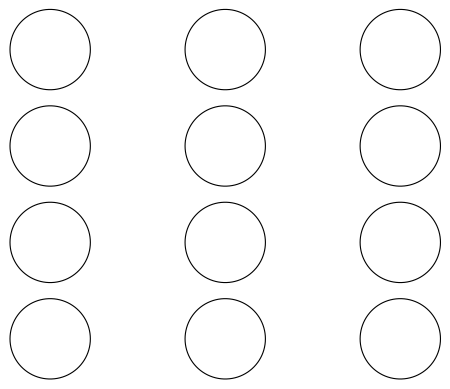

In [2]:
import xarray as xr
import gcsfs

gcs = gcsfs.GCSFileSystem(token="anon")

# Common ARCO ERA5 Zarr (newer "v3" store; large, but actively used)
path = "gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3"

ds = xr.open_zarr(
    gcs.get_mapper(path),
    chunks="auto",
    consolidated=True,
)

# # Always subset early (time/region/vars) to avoid massive reads
# sub = ds[["t2m", "u10", "v10"]].sel(
#     time=slice("2024-01-01", "2025-12-31"),
#     latitude=slice(90, 60),
#     longitude=slice(-60, 60),
# )

In [3]:
ds

<xarray.Dataset> Size: 4PB
Dimensions:                                                          (
                                                                      time: 1323648,
                                                                      latitude: 721,
                                                                      longitude: 1440,
                                                                      level: 37)
Coordinates:
  * latitude                                                         (latitude) float32 3kB ...
  * level                                                            (level) int64 296B ...
  * longitude                                                        (longitude) float32 6kB ...
  * time                                                             (time) datetime64[ns] 11MB ...
Data variables: (12/273)
    100m_u_component_of_wind                                         (time, latitude, longitude) float32 5TB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    100m_v_component_of_wind                                         (time, latitude, longitude) float32 5TB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    10m_u_component_of_neutral_wind                                  (time, latitude, longitude) float32 5TB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    10m_u_component_of_wind                                          (time, latitude, longitude) float32 5TB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    10m_v_component_of_neutral_wind                                  (time, latitude, longitude) float32 5TB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    10m_v_component_of_wind                                          (time, latitude, longitude) float32 5TB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    ...                                                               ...
    wave_spectral_directional_width_for_swell                        (time, latitude, longitude) float32 5TB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    wave_spectral_directional_width_for_wind_waves                   (time, latitude, longitude) float32 5TB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    wave_spectral_kurtosis                                           (time, latitude, longitude) float32 5TB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    wave_spectral_peakedness                                         (time, latitude, longitude) float32 5TB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    wave_spectral_skewness                                           (time, latitude, longitude) float32 5TB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    zero_degree_level                                                (time, latitude, longitude) float32 5TB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
Attributes:
    last_updated:           2025-12-13 02:01:39.878152+00:00
    valid_time_start:       1940-01-01
    valid_time_stop:        2025-09-30
    valid_time_stop_era5t:  2025-12-07

In [4]:
ds_sel = ds.sel(time='2024-04-04T12:00:00', latitude=78, longitude=4, method='nearest')


In [ ]:
ds_sub1 = ds.sel(latitude=slice(85, 65), longitude=slice(-20, 20),time=slice("2000-01-01", "2024-12-01"))

In [ ]:
ds_sub1

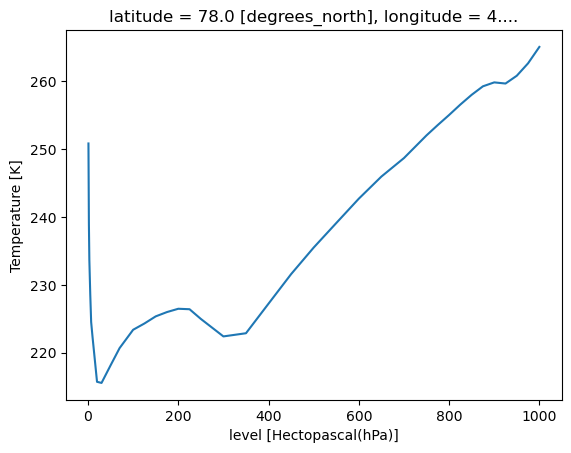

In [9]:
ds_sel.temperature.plot()

In [3]:
era5_to_sim = full_era5.rename({
    'sea_surface_temperature': 'surface_temperature',
    'temperature': 't',
    'specific_humidity': 'q',
    'geopotential': 'z',
    'level': 'pressure_level',
    'time' : 'valid_time',
})

## manually add ozone profile if not present
if 'o3' not in era5_to_sim.data_vars:
    # Use a constant profile for ozone, e.g., 300 DU
    # Convert DU to number density (1 DU = 2.687e19 molecules/m^2)
    # Assume a standard atmosphere for conversion
    altitude_km = era5_to_sim['z'] / 1000.0  # Convert geopotential height to km
    o3_profile = xr.DataArray(
        data=300e-6 * 2.687e19 * np.exp(-altitude_km / 8.5),  # Example exponential decay
        dims=era5_to_sim['z'].dims,
        coords=era5_to_sim['z'].coords,
        name='o3'
    )
    era5_to_sim = era5_to_sim.assign(o3=o3_profile)


In [11]:
# Import PyRadtran components using NEW IO system
from pyradtran.interface import PyRadtranAccessor  # This should register the accessor automatically
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from pathlib import Path
import pandas as pd


import logging
# change to "DEBUG" if you want to see more output
logging.getLogger('pyradtran').setLevel(logging.DEBUG)

N_timesteps = 32

# stationary simulation at constant altitude, latitude, and longitude but with varying time
# be aware that the max altitude needs to be lower than the max altitude in the ERA5 data

ds = xr.Dataset(
    coords={
        'time' : pd.date_range('2020-04-04T12:00:00', periods=N_timesteps, freq='d'),
        'latitude' : ('time', [51.336466] * N_timesteps),
        'longitude' : ('time', [12.375255] * N_timesteps),
        'altitude' : ('altitude', np.arange(0, 20, 1)),
    }
)



# load the ERA5 data for the specified space and time // this didn't make it faster...
ds_era5_local = era5_to_sim.sel(
    latitude=ds['latitude'],
    longitude=ds['longitude'],
    valid_time=ds['time'],
    method='nearest'
).load()

ds_era5_local = ds_era5_local.assign_coords(
    z = ds_era5_local['z'] / 9.81 / 1e3 # Convert geopotential height to km
)

In [12]:
# assign units to ERA5 variables
ds_era5_local['pressure_level'].attrs['units'] = 'hPa'
ds_era5_local['t'].attrs['units'] = 'K'
ds_era5_local['q'].attrs['units'] = 'kg kg**-1'
ds_era5_local['z'].attrs['units'] = 'm'
ds_era5_local['surface_temperature'].attrs['units'] = 'K'


ds_era5_local.q.units

'kg kg**-1'

In [13]:
# Load the configuration from the YAML file
config_path = Path('config/thermal_config.yaml')

ds_sim = ds.pyradtran.run(
    config_path=config_path,
    return_dataset=True,
    save_to_file=False,
    era5_atmosphere=ds_era5_local,  # Use the local ERA5 data
)

2025-12-13 17:33:44,710 - pyradtran.config - WARNING - Ignoring unknown config parameter: variable_encoding in OutputConfig
2025-12-13 17:33:44,711 - pyradtran.config - WARNING - Ignoring unknown config parameter: mol_modify in SimulationDefaults
2025-12-13 17:33:44,712 - pyradtran.config - WARNING - Ignoring unknown config parameter: mol_tau_file in SimulationDefaults
2025-12-13 17:33:44,712 - pyradtran.config - WARNING - Ignoring unknown config parameter: phi in SimulationDefaults
2025-12-13 17:33:44,712 - pyradtran.config - WARNING - Ignoring unknown config parameter: transmittance_source in SimulationDefaults
2025-12-13 17:33:44,713 - pyradtran.config - WARNING - Ignoring unknown config parameter: umu in SimulationDefaults
2025-12-13 17:33:44,713 - pyradtran.interface - INFO - ERA5 atmosphere dataset validated with 13 pressure levels
2025-12-13 17:33:44,714 - pyradtran.interface - INFO - Altitude found as coordinate - using 20 levels for zout: [ 0  1  2  3  4  5  6  7  8  9 10 11 1

## Distance between Requested Point and Nearest ERA5 Point

Compare the distance between the requested point and the nearest ERA5 point with the `haversine` function.

In [18]:

def haversine(lon1, lat1, lon2, lat2):
    # convert decimal degrees to radians
    lon1 = np.deg2rad(lon1)
    lon2 = np.deg2rad(lon2)
    lat1 = np.deg2rad(lat1)
    lat2 = np.deg2rad(lat2)

    # haversine formula
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    r = 6371
    return c * r

In [19]:
distances = haversine(
    ds['longitude'].values,
    ds['latitude'].values,
    ds_era5_local['longitude'].values,
    ds_era5_local['latitude'].values
)

print(f"Distances to nearest ERA5 point: {distances} km")

Distances to nearest ERA5 point: [168.43944596 168.43944596 168.43944596 168.43944596 168.43944596
 168.43944596 168.43944596 168.43944596 168.43944596 168.43944596
 168.43944596 168.43944596 168.43944596 168.43944596 168.43944596
 168.43944596 168.43944596 168.43944596 168.43944596 168.43944596
 168.43944596 168.43944596 168.43944596 168.43944596 168.43944596
 168.43944596 168.43944596 168.43944596 168.43944596 168.43944596
 168.43944596 168.43944596] km


## Investigating the simulation results

As the simulation results are stored in an xarray dataset, you can use the xarray plotting capabilities to visualize the results.

In [20]:
ds_era5_local.t

<xarray.DataArray 't' (time: 32, pressure_level: 13)> Size: 2kB
array([[214.94797, 213.31366, 213.96211, 207.48996, 214.59138, 223.99263,
        239.40698, 249.9818 , 260.3134 , 264.53793, 272.06534, 278.6144 ,
        283.88516],
       [210.4976 , 211.66722, 209.5003 , 205.55516, 217.01645, 227.01665,
        244.01733, 257.12854, 264.68958, 271.795  , 276.67307, 281.91183,
        287.3244 ],
       [209.58752, 213.16273, 212.3668 , 206.4207 , 217.14804, 226.42052,
        243.7111 , 256.3409 , 265.92407, 272.59778, 280.58215, 285.91367,
        291.2678 ],
       [211.64577, 212.78586, 212.5107 , 207.67154, 216.19234, 225.54921,
        241.31699, 254.38576, 264.21228, 270.64276, 280.13644, 286.3661 ,
        291.9816 ],
       [212.60658, 212.82393, 213.08173, 208.53116, 216.4376 , 225.60712,
        240.46614, 254.17343, 265.34637, 271.66043, 280.49554, 286.93924,
        292.4186 ],
       [211.49678, 212.16919, 213.97028, 209.488  , 215.72455, 225.37729,
        241.56468, 253.70395, 263.51636, 269.10303, 280.97543, 287.0054 ,
        292.39542],
       [211.61923, 211.63982, 212.72069, 206.54765, 216.21503, 226.43425,
        242.22891, 255.24002, 264.82718, 270.5359 , 278.62946, 285.31906,
...
        238.647  , 251.2577 , 260.93115, 267.30588, 277.49908, 283.83536,
        288.75992],
       [219.54202, 221.22334, 223.26399, 218.05643, 215.50783, 223.98744,
        240.51892, 251.74104, 260.3413 , 267.74512, 277.7631 , 284.16507,
        288.99625],
       [219.23811, 221.6651 , 224.47676, 226.6745 , 223.17247, 223.67531,
        236.24623, 248.1787 , 257.6214 , 265.5683 , 275.8356 , 282.3298 ,
        287.06787],
       [218.35735, 220.7873 , 224.46764, 226.89153, 225.30635, 227.26585,
        237.23328, 246.81331, 255.80331, 263.15793, 273.60858, 280.08047,
        284.9888 ],
       [217.0098 , 219.40974, 222.33041, 222.64043, 221.09558, 224.74612,
        239.21095, 249.57193, 259.13968, 263.9466 , 274.28775, 281.07733,
        286.32486],
       [217.72243, 219.378  , 220.67836, 217.87791, 219.56764, 227.67662,
        241.62872, 251.39725, 260.15826, 267.62112, 277.2223 , 282.81885,
        287.70538],
       [218.29552, 220.34204, 220.14468, 219.3455 , 221.41492, 229.79536,
        241.20216, 252.49088, 259.29648, 264.7286 , 272.9837 , 279.62222,
        284.80798]], dtype=float32)
Coordinates:
    z               (time, pressure_level) float32 2kB 20.34 16.01 ... 0.1525
    latitude        (time) float64 256B 50.0 50.0 50.0 50.0 ... 50.0 50.0 50.0
  * pressure_level  (pressure_level) int64 104B 50 100 150 200 ... 850 925 1000
    longitude       (time) float64 256B 11.25 11.25 11.25 ... 11.25 11.25 11.25
    valid_time      (time) datetime64[ns] 256B 2020-04-04T12:00:00 ... 2020-0...
  * time            (time) datetime64[ns] 256B 2020-04-04T12:00:00 ... 2020-0...
Attributes:
    long_name:      Temperature
    short_name:     t
    standard_name:  air_temperature
    units:          K

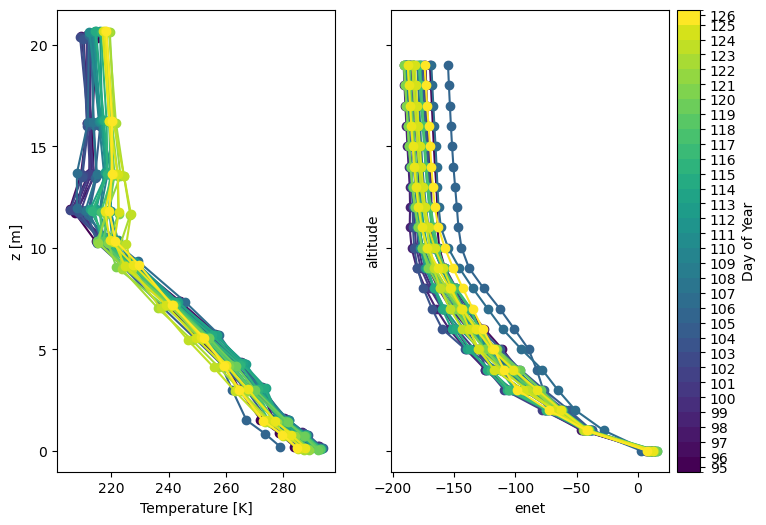

In [49]:
fig, ax = plt.subplots(1, 2, figsize=(10, 6), sharey=True, gridspec_kw={'width_ratios': [1, 1]})

from cycler import cycler

ax[0].set_prop_cycle(cycler('color', plt.cm.viridis(np.linspace(0, 1, len(ds_sim.time)))))
ax[1].set_prop_cycle(cycler('color', plt.cm.viridis(np.linspace(0, 1, len(ds_sim.time)))))


ds_sim.enet.plot(
    hue='time',
    y='altitude',
    marker='o',
    ax=ax[1],
    add_legend=False,
)

ds_era5_local.t.plot(
    hue='time',
    y='z',
    marker='o',
    ax=ax[0],
    add_legend=False,
)

# colorbar for the days 
import matplotlib.colors as mcolors

time_values = ds_sim.time.dt.dayofyear
n_colors = len(time_values)

# Create a colormap with discrete colors based on the viridis cycler
colors = plt.cm.viridis(np.linspace(0, 1, n_colors))
discrete_cmap = mcolors.ListedColormap(colors)

# Create boundaries for the discrete colormap
# Assuming lwc_values are ordered, calculate midpoints for boundaries
# If lwc_values are not ordered, sort them first: lwc_values.sort()
if n_colors > 1:
    boundaries = np.concatenate(([time_values[0] - (time_values[1] - time_values[0]) / 2],
                                 (time_values[:-1] + time_values[1:]) / 2,
                                 [time_values[-1] + (time_values[-1] - time_values[-2]) / 2]))
else: # Handle case with a single LWC value
    boundaries = np.array([time_values[0] - 0.5, time_values[0] + 0.5])


norm = mcolors.BoundaryNorm(boundaries, discrete_cmap.N, clip=True)

sm = plt.cm.ScalarMappable(cmap=discrete_cmap, norm=norm)
sm.set_array([]) # Required for ScalarMappable when not directly plotting data

cbar = fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.2, pad=0.01, ticks=time_values, label='Day of Year')